## Fetch and Display KRX Stock Data
KOSPI, 삼성전자, 하이닉스 

In [4]:
# _tsa_00.py
# time series stuff, basic 
# 그리기
# 시계열, 추세, 계절성 조정, 이동평균, 이런 것들. 
# 자기공분산, 자기상관, 단위근 
# ARIMA 중 AR(p)
# 기타... 단순한 내용만 간략하게. 

# 코랩 추가. 
!pip install yfinance 
#!pip install pykrx   # 이건 스크래핑, 무단 자료조회 모듈임. 스킵. 
!pip install finance-datareader

import os
import numpy as np                          # numpy 라이브러리 전체. 
import pandas as pd                         # pandas 라이브러리 전체, 시계열(기본) 여기 있네. 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yfinance as yf                       ## NYSE 데이터 모듈 
import FinanceDataReader as fdr             ## KOSPI, NYSE 
from scipy import stats, optimize, linalg   # scipy 라이브러리 하부 모듈.
from statsmodels.tsa import stattools       # time series analysis 
from statsmodels.tsa.arima.model import ARIMA # 이거 가능하다 이거지. 이거 대문자네. 꼭. 
from statsmodels.tsa.ar_model import AutoReg



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
# 1. 라이브러리 설치 (코랩의 경우 맨 앞에 ! 추가)
#!pip install yfinance
# import yfinance as yf

# 2. KOSPI 상장 종목 전체 가져오기
df_kospi = fdr.StockListing('KOSPI')
df_kospi.head()
#print(df_kospi.head())
#df_kospi = fdr.StockListing('KOSPI-DESC')
#print(df_kospi[['Code', 'Name', 'Sector']].head(7))
# 0  005930  KR7005930003    삼성전자  KOSPI  NaN   257000          2   -24500   
# 1  000660  KR7000660001  SK하이닉스  KOSPI  NaN  1688000          2   -42000   
# 2  005935  KR7005931001   삼성전자우  KOSPI  NaN   190500          2   -16500   
# 3  402340  KR7402340004   SK스퀘어  KOSPI  NaN  1072000          2   -51000   
# 4  009150  KR7009150004    삼성전기  KOSPI  NaN 



,Code,ISU_CD,Name,Market,Dept,Close,ChangeCode,Changes,ChagesRatio,Open,High,Low,Volume,Amount,Marcap,Stocks,MarketId
0,005930,KR7005930003,삼성전자,KOSPI,NaN,257000,2,-24500,-8.70,271500,272000,255000,32451940,8456072427750,1502493602256000,5846278608,STK
1,000660,KR7000660001,SK하이닉스,KOSPI,NaN,1671000,2,-59000,-3.41,1775000,1792000,1670000,3994599,6858026942000,1220652741915000,730492365,STK
2,005935,KR7005931001,삼성전자우,KOSPI,NaN,189300,2,-17700,-8.55,197400,197500,188500,6666892,1277722450200,151888868727900,802371203,STK
3,402340,KR7402340004,SK스퀘어,KOSPI,NaN,1076000,2,-47000,-4.19,1140000,1145000,1061000,458531,499665595500,141950221848000,131923998,STK
4,009150,KR7009150004,삼성전기,KOSPI,NaN,1318000,1,2000,0.15,1316000,1343000,1292000,501168,660074978500,98446291328000,74693696,STK


In [6]:

# 1. 삼성전자(005930)의 2025년부터 현재까지의 주가 데이터 수집
ticker = '005930'    # 삼서전자 코드, 티커.
df_dat = fdr.DataReader(ticker, '2023-01-01')  # 삼성전자 코드 
ticker_2 = '000660'  # hynix 
df_dat_2 = fdr.DataReader(ticker_2, '2023-01-01')  # 삼성전자 코드 

# # 2. 가격(종가) 데이터 읽기
# # 최신 버전 FinanceDataReader의 주가 컬럼명은 'Close'입니다.
prc_cls = df_dat['Close']
prc_cls_hy = df_dat_2['Close'] 
# # 3. 거래량(볼륨) 데이터 읽기
vlm = df_dat['Volume']
vlm_2 = df_dat_2['Volume']

# # 4. 상위 5개 데이터 결합해서 눈으로 확인하기
# print(df_dat[['Close', 'Volume']].head())
# print(df_dat.head(15) )

# 이것은 NYSE 
# ticker = 'TSLA' 
# df_dat = yf.download(ticker, period='5y', multi_level_index=False)
df_dat.head()
#df_tesla.info()

# (만약 굳이 내 컴퓨터에 CSV 파일로 보관하고 싶다면 아래 주석 제거)
# df_dat.to_csv("tesla_historical_data.csv")



,Open,High,Low,Close,Volume,Change
Date,,,,,,
2023-01-02,55500,56100,55200,55500,10031448,0.003617
2023-01-03,55400,56000,54500,55400,13547030,-0.001802
2023-01-04,55700,58000,55600,57800,20188071,0.043321
2023-01-05,58200,58800,57600,58200,15682826,0.006920
2023-01-06,58300,59400,57900,59000,17334989,0.013746


In [7]:
# NYSE daily stock prices and trading volumes 
# 변수로 받는 방법. 
yymmdd = df_dat.index   # 자료를 불러올 때, 자동으로 기준 인덱스로 설정된다고 함.
yymmdd = pd.to_datetime( yymmdd )

stck_prc = df_dat['Close']
stck_prc_dff = stck_prc.diff() 
stck_prc_pct = stck_prc.pct_change()

stck_vlm = df_dat['Volume']
stck_vlm_dff = stck_vlm.diff() 
stck_vlm_pct = stck_vlm.pct_change()

stck_prc_2 = df_dat_2['Close']
stck_prc_dff_2 = stck_prc_2.diff() 
stck_prc_pct_2 = stck_prc_2.pct_change()

stck_vlm_2 = df_dat_2['Volume']
stck_vlm_dff_2 = stck_vlm_2.diff() 
stck_vlm_pct_2 = stck_vlm_2.pct_change()


### time series plots

Text(0.5, 1.0, ' Closing Prices of 000660 ')

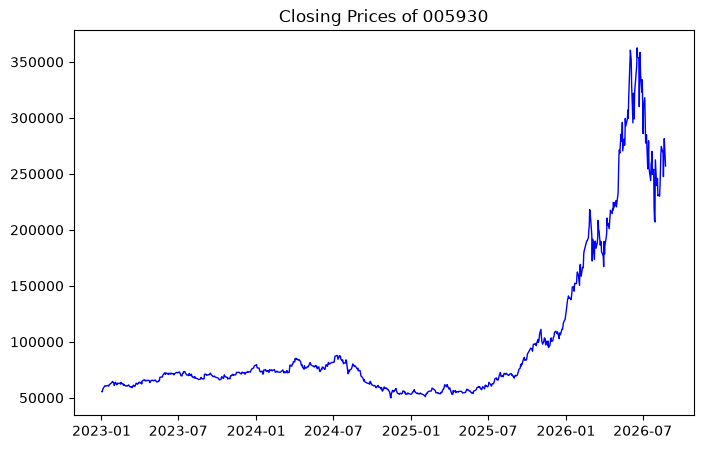

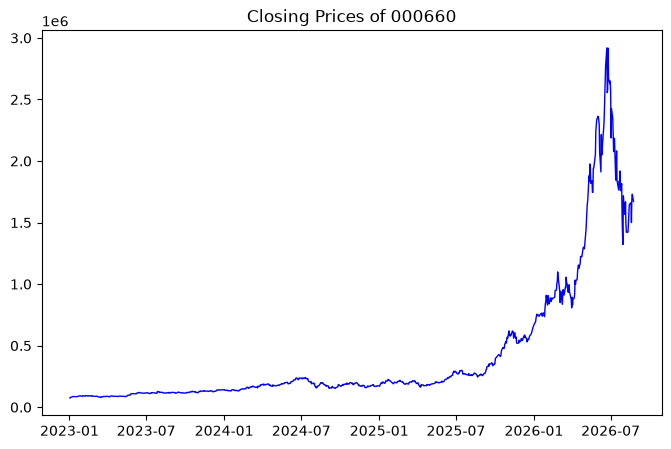

In [11]:

plt.figure(figsize=(8, 5))
#plt.subplot(figsize=(8,5  ))
plt.plot(yymmdd, stck_prc, color='blue', linewidth=1)
plt.title(f" Closing Prices of {ticker} ") 

plt.figure(figsize=(8, 5))
#plt.subplot(figsize=(8,5  ))
plt.plot(yymmdd, stck_prc_2, color='blue', linewidth=1)
plt.title(f" Closing Prices of {ticker_2} ") 


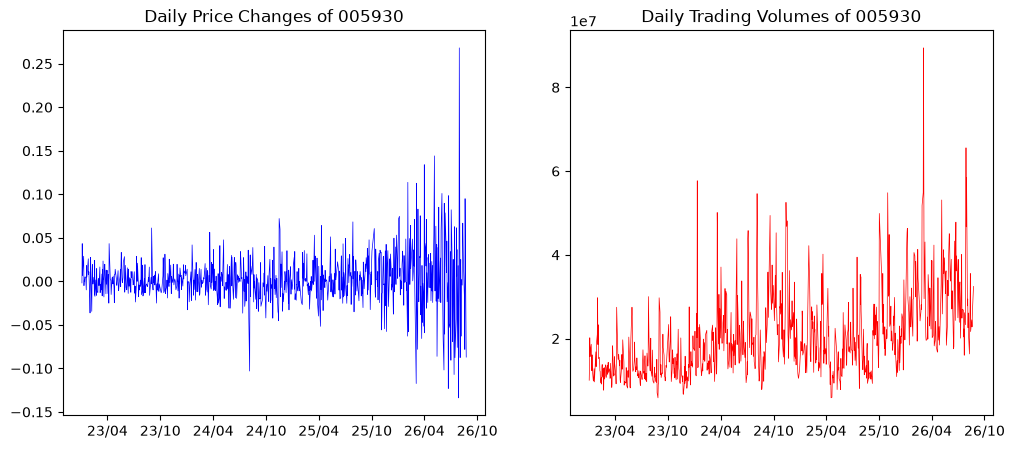

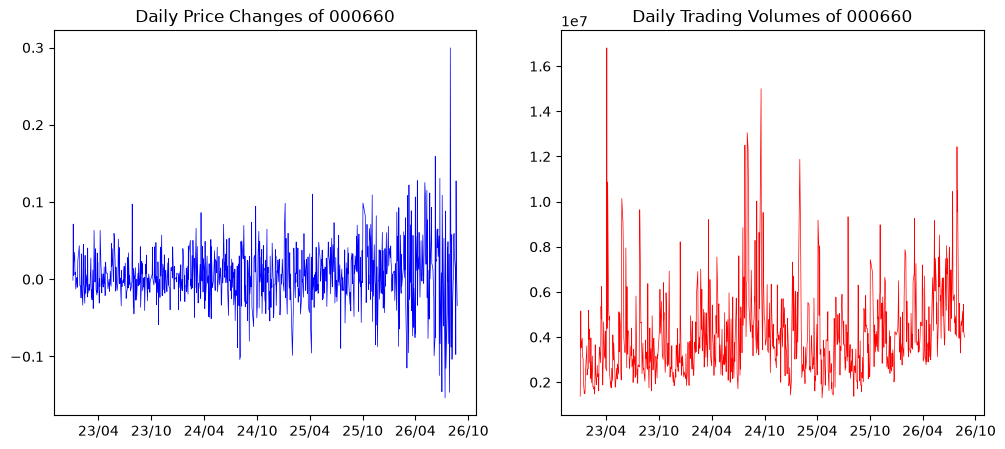

In [13]:

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
#axes[0].plot(yymmdd, stck_prc, color='blue', linewidth=0.5)
axes[0].plot(yymmdd, stck_prc_pct, color='blue', linewidth=0.5)
axes[1].plot(yymmdd, stck_vlm, color='red', linewidth=0.5) 
# axes[0].set_title(f" Closing Prices of {ticker} ") 
axes[0].set_title(f" Daily Price Changes of {ticker} ") 
axes[1].set_title(f" Daily Trading Volumes of {ticker} ") 
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%y/%m'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%y/%m'))

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
#axes[0].plot(yymmdd, stck_prc, color='blue', linewidth=0.5)
axes[0].plot(yymmdd, stck_prc_pct_2, color='blue', linewidth=0.5)
axes[1].plot(yymmdd, stck_vlm_2, color='red', linewidth=0.5) 
# axes[0].set_title(f" Closing Prices of {ticker} ") 
axes[0].set_title(f" Daily Price Changes of {ticker_2} ") 
axes[1].set_title(f" Daily Trading Volumes of {ticker_2} ") 
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%y/%m'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%y/%m'))


Text(0.5, 1.0, ' distribution of daily percentage change of 000660 ')

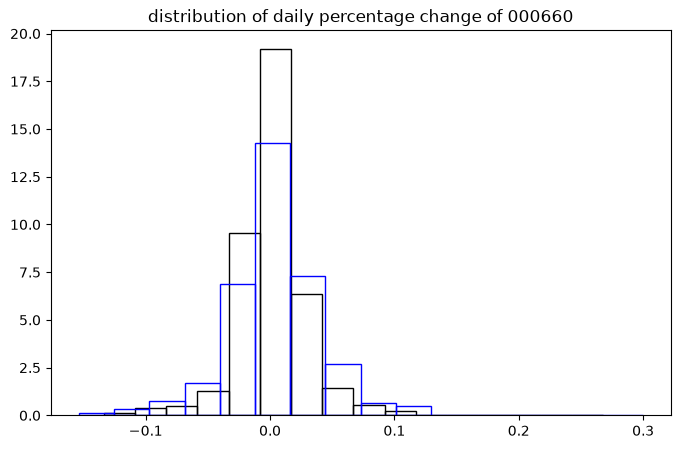

In [15]:

plt.figure(figsize=(8, 5))
plt.hist(stck_prc_pct, 
         color='blue', 
         linewidth=1, 
         bins = 16, 
         facecolor='None', 
         edgecolor='black', 
         density=True
         )
plt.title(f" distribution of daily percentage change of {ticker} ") 

plt.hist(stck_prc_pct_2, 
         color='blue', 
         linewidth=1, 
         bins = 16, 
         facecolor='None', 
         edgecolor='blue', 
         density=True
         )
plt.title(f" distribution of daily percentage change of {ticker_2} ") 
